In [94]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Modelled after damicelli's work. 

import numpy as np
from typing import List, Dict, Optional, Any


from src.ESNs.utils_math import _entropy, _calculate_information_dynamics, _calculate_branching_ratio
import echoes
import numpy as np
from scipy.stats import pearsonr

from vizman import viz


print(os.getcwd())  # Should show the project root 

# from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES, REPRESENTATIVES_FOR_GOALS

# from config import COLOR_SCHEME, CATEGORY_COLOURS, CATEGORY_ORDER

%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
from src.ESNs.memory_capacity_weighted import evaluate_memory_capacity_from_connectome, evaluate_nonlinear_capacity_from_connectome, evaluate_nonlinear_capacity

In [96]:

LABEL_MAP = {
    "hcp_schaefer_100_dataset_gnm": "HCP (GNM)",
    "hcp_schaefer_100_dataset": "HCP (Empirical)",
    "kaysons_generated_networks_diffusion": "Diffusion",
    "kaysons_generated_networks_propagation": "Propagation",
    "kaysons_generated_networks_routing": "Routing",
    "suarez_MaMI_dataset": "MaMI",
    "lexis_data_developing": "Developing",
}


In [97]:
A = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_connectomes_density10.npy")[0]
A = np.array(A, dtype=np.float32)
A.shape

(100, 100)

0.09520546346902847 0.08651840686798096


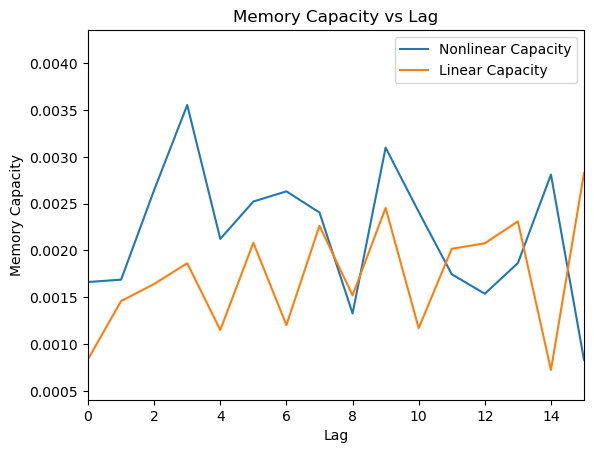

In [98]:
# h_params = {
#             "spectral_radius": 0.9, # 0.9
#             "n_lags": 15, 
#             "train_len": 5000,
#             "test_len": 1000,
#             "n_runs": 10, # 50,
#             "input_scaling": 0.5, # 1.0,
#             "regression_method": "ridge", # pinv",
#             "n_transient": 100, # 100,
#             "leak_rate": 0.3, # 3, #3, # 5, # 1.0,
#             "bias": 0.5, # 1.0,
#             "random_state": 42
#         }

h_params = {
            "spectral_radius": 0.99, # 0.9
            "n_lags": 41, # 15, 
            "train_len": 2400, # 5000,
            "test_len": 600, # 1000,
            "n_runs": 10, # 50,
            "input_scaling": 1e-5, # 0.5, # 1.0,
            "regression_method": "pinv", # default
            "n_transient": 100, # 100,
            "leak_rate": 1, # 0.5, #1, # default
            "bias": 1, # default
            "random_state": 42
        }


results_nonlin = evaluate_nonlinear_capacity_from_connectome(np.float64(A), h_params=h_params)
results_lin = evaluate_memory_capacity_from_connectome(np.float64(A), h_params=h_params)

plt.plot(results_nonlin["mc_values_for_indiv_lags"], label="Nonlinear Capacity")
plt.plot(results_lin["mc_values_for_indiv_lags"], label="Linear Capacity")
plt.xlabel("Lag")
plt.ylabel("Memory Capacity")
plt.title("Memory Capacity vs Lag")
plt.legend()
plt.xlim(0, 15) # h_params["n_lags"])
print(results_nonlin["mc_mean"], results_lin["mc_mean"])

In [99]:
# Produce data once 

lags=np.arange(1, 41)
X, y = make_X_y(
    make_X=partial(np.random.uniform, low=0, high=1, size=3000),
    lags=lags,
    cut=0
)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2400, 1), (600, 1), (2400, 40), (600, 40))

In [100]:
evaluate_memory_capacity_from_connectome

<function src.ESNs.memory_capacity_weighted.evaluate_memory_capacity_from_connectome(connectome: numpy.ndarray, h_params: Optional[Dict[str, Any]] = None, calculate_criticality: Optional[bool] = False, calculate_info_dynamics: Optional[bool] = False) -> Dict[str, float]>

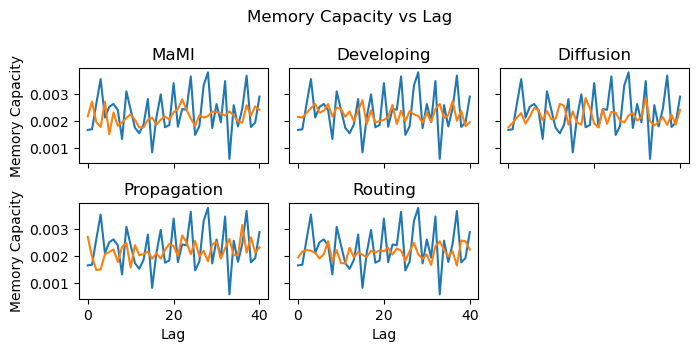

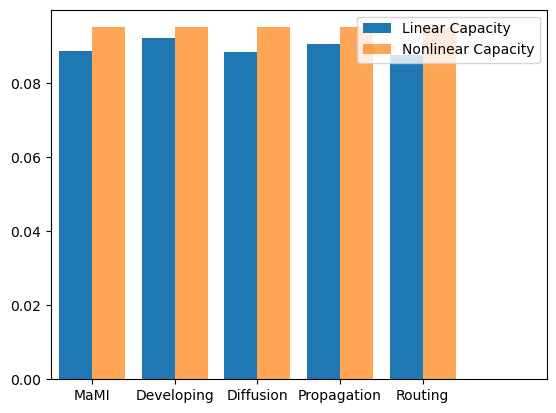

In [101]:
h_params = {
            "spectral_radius": 0.99, # 0.9
            "n_lags": 41, # 15, 
            "train_len": 2400, # 5000,
            "test_len": 600, # 1000,
            "n_runs": 100, # 50,
            "input_scaling": 1e-5, # 0.5, # 1.0,
            "regression_method": "pinv", # default
            "n_transient": 100, # 100,
            "leak_rate": 1, # default
            "bias": 1, # default
            "random_state": 42
        }

# 0.99, trial: 100, 
# 1e-5, 
# Uniform: 0, 1, 
# Total: 3000 -> 20% test
# Lags: 1, 41
# Trials: 100
# Activation function: default 
# Leak rate: 1, noise is zero 
# Transient 100


ordered_dataset_names_and_paths = {
                        # 'hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        'suarez_MaMI_dataset': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy", 
                        # 'lexis_data_young', 
                        # 'lexis_data_aging',
                        'lexis_data_developing': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_individual_connectomes_bin.npy", 
                        'kaysons_generated_networks_diffusion': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion_10_percent.npy", # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        'kaysons_generated_networks_propagation': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_10_percent.npy", # Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        'kaysons_generated_networks_routing': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/routing_10_percent.npy", # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        # 'kaysons_generated_networks_topology': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_topology/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        }

fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 9)), sharey=True, sharex=True)

total_mc_lin = []
total_mc_nonlin = []

for i, ((dataset, dataset_path), ax) in enumerate(zip(ordered_dataset_names_and_paths.items(), axs.flatten())):
    A = np.load(dataset_path)[0]
    A = np.array(A, dtype=np.float32)
    
    # results_nonlin = evaluate_nonlinear_capacity_from_connectome(np.float64(A), h_params=h_params)
    results_lin = evaluate_memory_capacity_from_connectome(np.float64(A), h_params=h_params)

    ax.plot(results_nonlin["mc_values_for_indiv_lags"], label="Nonlinear Capacity")
    ax.plot(results_lin["mc_values_for_indiv_lags"], label="Linear Capacity")
    ax.set_title(LABEL_MAP[dataset])
    
    if i % 3 == 0:  # Only set y-labels for the first column
        ax.set_ylabel("Memory Capacity")
    if i >= 3: 
        ax.set_xlabel("Lag")
        
    total_mc_lin.append(np.sum(results_lin["mc_mean"]))
    total_mc_nonlin.append(np.sum(results_nonlin["mc_mean"]))

# remove unused subplots
for j in range(i+1, len(axs.flatten())):
    fig.delaxes(axs.flatten()[j])
    
plt.suptitle("Memory Capacity vs Lag")
    # ax.legend()
plt.tight_layout()

plt.show() 




# Add for the last subplot a barplot with all the datasets' total MCs (sum across lags) for both linear and nonlinear, to compare overall performance across datasets.
plt.bar(np.arange(len(total_mc_lin))-0.2, width=0.4, height=total_mc_lin, label="Linear Capacity")
plt.bar(np.arange(len(total_mc_nonlin))+0.2, width=0.4, height=total_mc_nonlin, label="Nonlinear Capacity", alpha=0.7)
plt.xticks(np.arange(len(ordered_dataset_names_and_paths)), 
           [LABEL_MAP[key] for key in ordered_dataset_names_and_paths.keys()], 
           )
plt.xlim(-0.5, len(ordered_dataset_names_and_paths)+0.5)
plt.legend()

In [102]:
results_nonlin

{'mc_mean': 0.09520546346902847,
 'mc_std': 0.02449919283390045,
 'mc_values_for_indiv_lags': array([0.00166343, 0.00168868, 0.00264561, 0.00355294, 0.00212365,
        0.00252254, 0.00263116, 0.00240528, 0.00132814, 0.00309804,
        0.00241243, 0.00174621, 0.00153832, 0.00186589, 0.00281049,
        0.00082961, 0.00212837, 0.00298286, 0.00176427, 0.00184712,
        0.00340365, 0.00178483, 0.00244094, 0.00241327, 0.00365211,
        0.00147863, 0.00180509, 0.00331727, 0.00380463, 0.00173653,
        0.00262723, 0.00195207, 0.00348082, 0.00058643, 0.00258337,
        0.00179335, 0.00246297, 0.0036845 , 0.00177496, 0.00193501,
        0.00290276], dtype=float32),
 'h_params': {'spectral_radius': 0.99,
  'n_lags': 41,
  'train_len': 2400,
  'test_len': 600,
  'n_runs': 10,
  'input_scaling': 1e-05,
  'regression_method': 'pinv',
  'n_transient': 100,
  'leak_rate': 1,
  'bias': 1,
  'random_state': 42}}

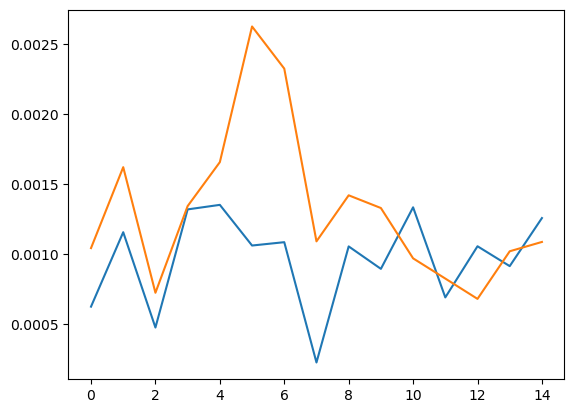

In [103]:
h_params = {
            "spectral_radius": 0.9, # 0.9
            "n_lags": 15, 
            "train_len": 5000,
            "test_len": 1000,
            "n_runs": 10, # 50,
            "input_scaling": 1, # 0.5, # 1.0,
            "regression_method": "ridge", # pinv",
            "n_transient": 100, # 100,
            "leak_rate": 0.5, # 0.9, # 3, #3, # 5, # 1.0,
            "bias": 1, # 1.0,
            "random_state": 42
        }

results_nonlin = evaluate_nonlinear_capacity_from_connectome(np.float64(A), h_params=h_params)
results_lin = evaluate_memory_capacity_from_connectome(np.float64(A), h_params=h_params)

plt.plot(results_nonlin["mc_values_for_indiv_lags"], label="Nonlinear Capacity")
plt.plot(results_lin["mc_values_for_indiv_lags"], label="Linear Capacity")

In [104]:
from utils_kayson_damicelli import forgetting, make_X_y
from functools import partial
from sklearn.model_selection import train_test_split

In [105]:
lags=np.arange(1, 41)
X, y = make_X_y(
    make_X=partial(np.random.uniform, low=0, high=1, size=3000),
    lags=lags,
    cut=0
)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2400, 1), (600, 1), (2400, 40), (600, 40))

In [106]:
from echoes import ESNRegressor

In [107]:
summed_r2s = [] 
r2s = []

for trial in range(10):          
    # Propagation
    esn = ESNRegressor(W=np.array(A, dtype=np.float32), # propagation_matrices[...,subject],
                        input_scaling=1e-5,
                        n_transient=100,
                        # W_in=A, # propagation_mask[subject][:,np.newaxis],
                        random_state=42+trial) # subject+trial)
    y_pred = esn.fit(X_train, y_train).predict(X_test)
    result = forgetting(y_test[100:], y_pred[100:])
    summed_r2s.append(result[1])
    r2s.append(result[0])
    
    
    # Empirical
    # esn = ESNRegressor(W=thresholded_connectivities[...,subject],
    #                     input_scaling=1e-5,
    #                     n_transient=100,
    #                     W_in=empirical_mask[subject][:,np.newaxis],
    #                     random_state=subject+trial)
    # y_pred = esn.fit(X_train, y_train).predict(X_test)
    # empirical_performances[trial,subject,idx]=ut.forgetting(y_test[100:], y_pred[100:])[1]
    
results

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<intrinsic _impl>) found for signature:
 
 >>> _impl(array(float32, 2d, C), array(float64, 1d, C))
 
There are 2 candidate implementations:
 - Of which 2 did not match due to:
 Intrinsic in function 'dot_2_impl.<locals>._impl': File: numba/np/linalg.py: Line 554.
   With argument(s): '(array(float32, 2d, C), array(float64, 1d, C))':
  Rejected as the implementation raised a specific error:
    TypingError: '@' arguments must all have the same dtype
  raised from /opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numba/np/linalg.py:574

During: resolving callee type: Function(<intrinsic _impl>)
During: typing of call at /opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numba/np/linalg.py (593)

File "../../../../../../opt/miniconda3/envs/ma_th

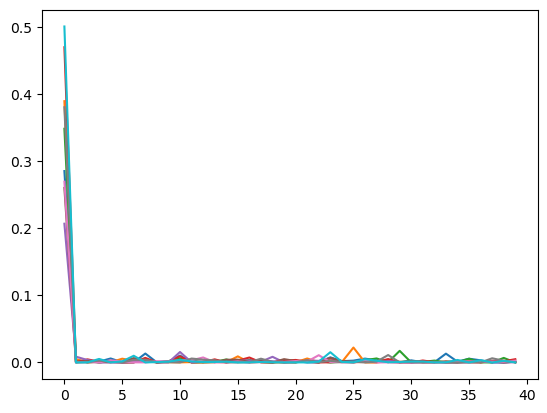

In [ ]:
plt.plot(np.array(r2s).T)   

(2400, 1) (600, 1) (2400, 40) (600, 40)


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


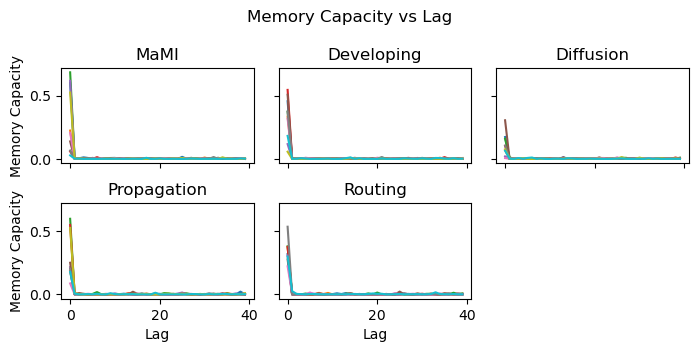

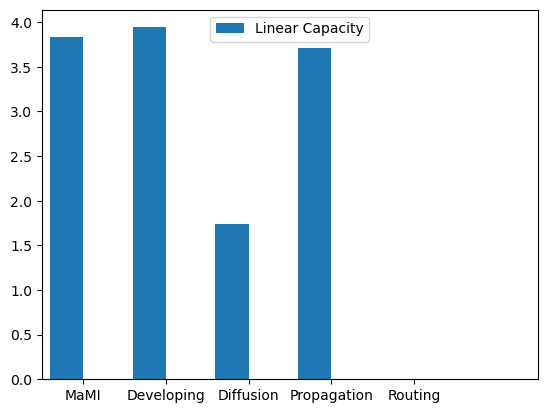

In [ ]:
h_params = {
            "spectral_radius": 0.99, # 0.9
            "n_lags": 41, # 15, 
            "train_len": 2400, # 5000,
            "test_len": 600, # 1000,
            "n_runs": 100, # 50,
            "input_scaling": 1e-5, # 0.5, # 1.0,
            "regression_method": "pinv", # default
            "n_transient": 100, # 100,
            "leak_rate": 1, # default
            "bias": 1, # default
            "random_state": 42
        }

# 0.99, trial: 100, 
# 1e-5, 
# Uniform: 0, 1, 
# Total: 3000 -> 20% test
# Lags: 1, 41
# Trials: 100
# Activation function: default 
# Leak rate: 1, noise is zero 
# Transient 100

# Generate X and y once 
lags=np.arange(1, 41)
X, y = make_X_y(
    make_X=partial(np.random.uniform, low=0, high=1, size=3000),
    lags=lags,
    cut=0
)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.2)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



ordered_dataset_names_and_paths = {
                        # 'hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        'suarez_MaMI_dataset': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy", 
                        # 'lexis_data_young', 
                        # 'lexis_data_aging',
                        'lexis_data_developing': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_individual_connectomes_bin.npy", 
                        'kaysons_generated_networks_diffusion': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion_10_percent.npy", # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        'kaysons_generated_networks_propagation': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_10_percent.npy", # Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        'kaysons_generated_networks_routing': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/routing_10_percent.npy", # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        # 'kaysons_generated_networks_topology': "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_topology/01_connectomes/00_connectomes_50_bin_wo_idx_95.npy",
                        }

fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 9)), sharey=True, sharex=True)

total_mc_lin = []
# total_mc_nonlin = []
    
    
for i, ((dataset, dataset_path), ax) in enumerate(zip(ordered_dataset_names_and_paths.items(), axs.flatten())):
    A = np.load(dataset_path)[0]
    
    summed_r2s = [] 
    r2s = []

    for trial in range(10):          
        # Propagation
        esn = ESNRegressor(W=np.array(A, dtype=np.float32), # propagation_matrices[...,subject],
                            input_scaling=1e-5,
                            n_transient=100,
                            # W_in=A, # propagation_mask[subject][:,np.newaxis],
                            random_state=42+trial) # subject+trial)
        y_pred = esn.fit(X_train, y_train).predict(X_test)
        result = forgetting(y_test[100:], y_pred[100:])
        summed_r2s.append(result[1])
        r2s.append(result[0])
    
    
    # results_nonlin = evaluate_nonlinear_capacity_from_connectome(np.float64(A), h_params=h_params)
    # results_lin = evaluate_memory_capacity_from_connectome(np.float64(A), h_params=h_params)

    ax.plot(np.array(r2s).T) 
    # ax.plot(summed_r2s, label="Linear Capacity")
    ax.set_title(LABEL_MAP[dataset])
    
    if i % 3 == 0:  # Only set y-labels for the first column
        ax.set_ylabel("Memory Capacity")
    if i >= 3: 
        ax.set_xlabel("Lag")

    total_mc_lin.append(np.sum(summed_r2s))
    # total_mc_nonlin.append(np.sum(r2s))

# remove unused subplots
for j in range(i+1, len(axs.flatten())):
    fig.delaxes(axs.flatten()[j])
    
plt.suptitle("Memory Capacity vs Lag")
    # ax.legend()
plt.tight_layout()

plt.show() 




# Add for the last subplot a barplot with all the datasets' total MCs (sum across lags) for both linear and nonlinear, to compare overall performance across datasets.
plt.bar(np.arange(len(total_mc_lin))-0.2, width=0.4, height=total_mc_lin, label="Linear Capacity")
# plt.bar(np.arange(len(total_mc_nonlin))+0.2, width=0.4, height=total_mc_nonlin, label="Nonlinear Capacity", alpha=0.7)
plt.xticks(np.arange(len(ordered_dataset_names_and_paths)), 
           [LABEL_MAP[key] for key in ordered_dataset_names_and_paths.keys()], 
           )
plt.xlim(-0.5, len(ordered_dataset_names_and_paths)+0.5)
plt.legend()